# The basics of Machine Learning

## 1 - Classification versus regression

In supervised learning, two classes of problems can be distinguished according to the kind of an output target data $y^t$ :

*   When $y^t$ is continuous ($y^t \in \mathbb{R}$) it is a regression problem;
*   When $y^t$ is discrete or category (like $y^t \in \{0,1\}$) it is a classification problem.

## 2 - Training a ML model

The data set, which is composed of data samples $(X_j,Y^t_j)_{j \in \{1,\dots,n\}}$, where $X_j=\left(x_{1j},\dots,x_{Ij}\right)$ and $Y^t_j=\left(y^t_{1j},\dots,y^t_{Oj}\right)$ with $I$ and $O$ being the number of input and output variables respectively,, is usually divided into three sets (examples possible splitting ratio are given between brackets; their sum must be always equal to 100%):
1.   training / learning set $(X_{train},Y^t_{train})$ (60%; 70%; 70%)
2.   validation set $(X_{validation},Y^t_{validation})$ (20%; 15%; 0%)
3.   test set $(X_{test},Y^t_{test})$ (20%; 15%; 30%)

The training set contains the data used to find the model's optimal parameters, while the validation set is used to check whether the training is still relevant or whether an overfit appears, meaning that the model is no longer able to generalize and therefore give good predictions for the new data encountered. The test set is used to evaluate the model's performance once training is complete.

Finding a model's optimal parameters means to find a set of parameters $\Theta$ (the set of synaptic weights $W$ in the context of a neural network) such that the model gives good predictions $Y$ for inputs $X$ considering a giving configuration of model's hyperparameters (learning rate, tree depth, and so on). This is done by finding a set $\hat{\Theta}$ that minimizes an Error / Loss function $L$ that drives the training
$$ \min_{\Theta} \left[ \frac{1}{n} \sum_{j=1}^{n} L\left(P_\Theta(X_j),Y^t_j\right) \right]$$
where $P_\Theta(X_j)$ is the model's prediction for a data sample $(X_j,Y^t_j)$ belonging to $(X_{train},Y^t_{train})$.

A common choice for the loss function is the Mean Squared Error $\rightarrow L\left(y,y^t\right) = \frac{1}{2} \left(y - y^t\right)^2$, where $\frac{1}{2}$ can be dropped.

## 3 - Evaluating the performance of a Machine Learning model

Once $\hat{\Theta}$ found, the model is evaluated on the test set $(X_{test},Y^t_{test})$ using a metric $d(P_{\hat{\Theta}}(X_{test}),Y^t_{test}) \in \mathbb{R}$, which can the loss function $L$ or another one not used for training.

## 4 - Optimization of hyperparameters

Once the model trained and evaluated, a further step is to optimize the hyperparameters of the model. This is one of the work a data scientist needs to complete. Indeed, for a given problem he must not only find the most suited machine learning model, but also find the best hyperparameters.

# What are you going to do?

In this lab you'll first train and evaluate the logistic regression model. Then in Lab2 another regression problem will be faced using decision trees and random forests.

In this Colab notebook you have to complete following steps:
1.   Download and open the following [data set](https://drive.google.com/file/d/1qvu1iWhoWm7TdlLOUpfS2p-8mwn5Xwbo/view?usp=sharing) using pandas
2.   Visualize the data and show the histogram of wines ratings
3.   Split the data set in train and test sets. Does the distribution of scores vary between the train and the test? Compared to the original dataset? How can a balanced separation be achieved?
4.   What is the nature of each feature? What do you notice? Adapt the dataset accordingly.
5.   Train a classifier with scikit-learn: logistic regression and evaluate its performance using scikit-learn and metrics adapted to classification.



## 1 - Mount the Google drive and load the data set

In [2]:

# 1 - Mount the Google drive
from google.colab import files
uploaded = files.upload()

Saving wines-quality.csv to wines-quality.csv


In [ ]:
!ls -l gdrive/'My Drive'/'Colab Notebooks'

In [3]:
# 2 - Load raw data
import pandas as pd
df = pd.read_csv("wines-quality.csv")

## 2 - Visualize data, display an histogram showing the wine ratings (*quality values*) distribution

In [4]:
# 1 - Display columns names
print(df.columns)

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'color'],
      dtype='object')


In [5]:
# 2 - Show the top rows of the data
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


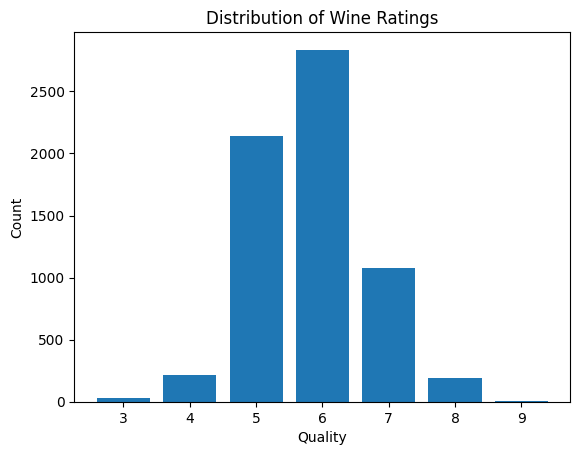

In [6]:
# 3 - Plot the wine ratings
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.hist(df['quality'], bins=range(3, 11), align='left', rwidth=0.8)
ax.set_xlabel('Quality')
ax.set_ylabel('Count')
ax.set_title('Distribution of Wine Ratings')
plt.show()

## 3 - First, define $Y$ (output) as the *quality* values and $X$ as the remaining columns. Second, split the data set into train and test sets (split ratio of 50%) using a function from [scikit-learn](https://scikit-learn.org/stable/)'s *Model selection*. What can you say about the data distribution of both sets (*display them in an histogram*). Third, use parameter *stratify* to obtain the same distribution of the ratings, especially for the one with the fewest occurrences (extreme values). Once done display the new histogram to show the result.

In [7]:
from sklearn.model_selection import train_test_split
# 1 - Define X and Y
X = df.drop('quality', axis=1)
y = df['quality']
# 2 - Split data set into training and test sets using a ratio of 50%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)
X_train.shape, X_test.shape

((3248, 12), (3249, 12))

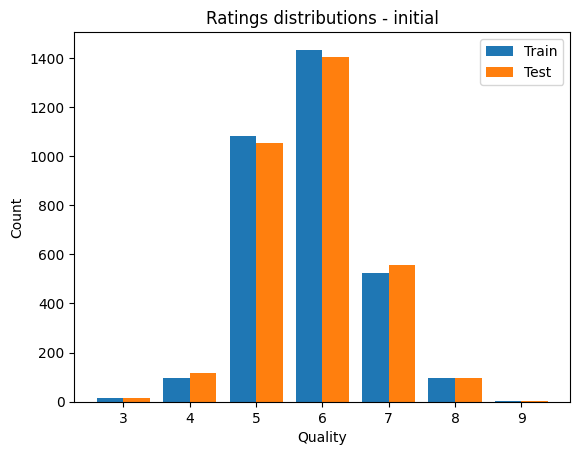

In [9]:
# 3 - Display the both data samples distributions (train and test)
plt.hist([y_train, y_test], bins=range(3, 11), align='left', label=['Train', 'Test'])
plt.xlabel('Quality')
plt.ylabel('Count')
plt.title("Ratings distributions - initial")
plt.legend()
plt.show()

(3248, 12) (3249, 12)


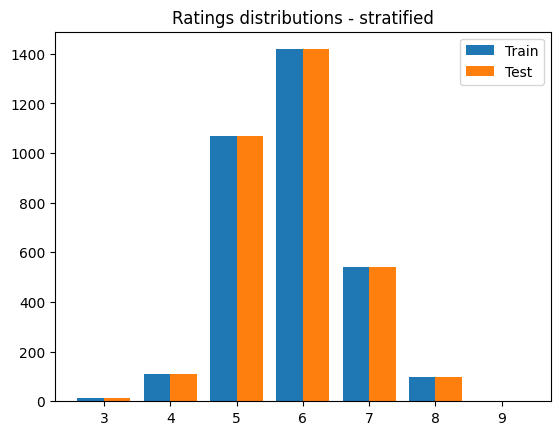

In [10]:
# 4 - Stratify the way the samples are distributed into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)
print(X_train.shape, X_test.shape)
fig, ax = plt.subplots()
ax.hist([y_train, y_test], bins=range(3, 11), align='left', label=['Train', 'Test'])
ax.set_title("Ratings distributions - stratified")
ax.legend();

## 4 - First, what are the types (integer, float, and so on) of values of the different variables / features of an input sample X? Second, what can you notice? Third, update the problematic variable / feature such that it becomes numeric and then split again the data set into train and test sets, but such that their respective ratio is 70% and 30%.

In [11]:
# 1 - Show the types
print(df.dtypes)

fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
color                    object
dtype: object


In [12]:
# 2 - Show the possible values of the problematic variable / feature
print(df['color'].unique())

['red' 'white']


In [13]:
# 3 - Update variable to become a numerical value
df['color'] = df['color'].map({'red': 0, 'white': 1})
df.fillna(df.mean(), inplace=True)

# 4 - Split again data set into train and test sets
X = df.drop('quality', axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
print(df.dtypes)

fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
color                     int64
dtype: object


## 5 - First, train a classifier using logistic regression from *Linear model* in scikit-learn. Second, display the prediction obtained for each of the five first samples of the test set. Third, use the function classification_report of scikit-learn to evaluate the classifier's performance. What is support value? How are computed precision, recall and f1-score? What are macro and weighted averaging? What can you conclude from the values?

In [14]:
# 1a - Try to train logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=500)

In [15]:
# 1b - Train logistic regression again using StandardScaler as preprocessing
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

lr_scaled = LogisticRegression(max_iter=500)
lr_scaled.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=500)

In [16]:
# 2 - Predict value for the five first test samples
X_test_scaled = scaler.transform(X_test)

Y_pred = lr_scaled.predict(X_test_scaled[:5])
print(Y_pred)

[6 6 5 6 6]


In [17]:
# 3 - Show classification performance using function classification_report of metrics
from sklearn.metrics import classification_report

y_pred = lr_scaled.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.50      0.02      0.03        65
           5       0.57      0.54      0.55       642
           6       0.51      0.70      0.59       851
           7       0.53      0.26      0.35       324
           8       0.00      0.00      0.00        58
           9       0.00      0.00      0.00         1

    accuracy                           0.53      1950
   macro avg       0.30      0.22      0.22      1950
weighted avg       0.51      0.53      0.50      1950



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
